Model trained successfully!


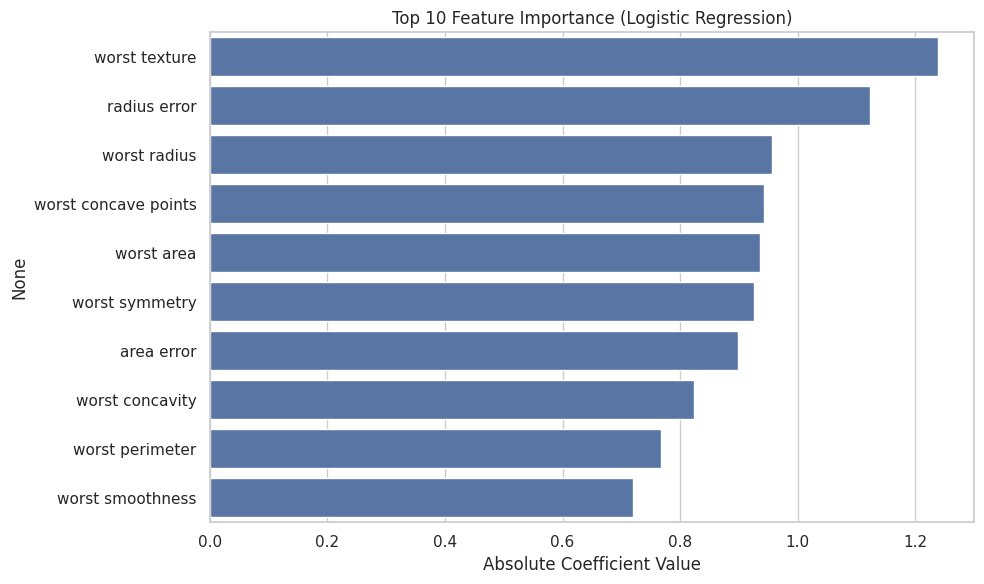

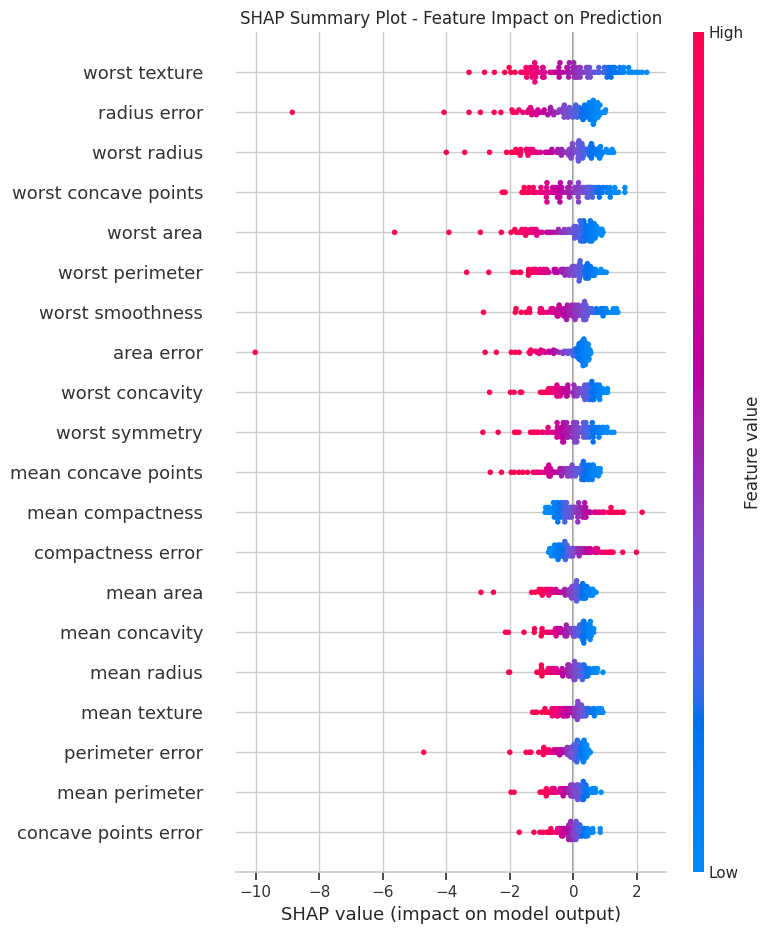


Local Explanation for Sample #0 (Test Set)


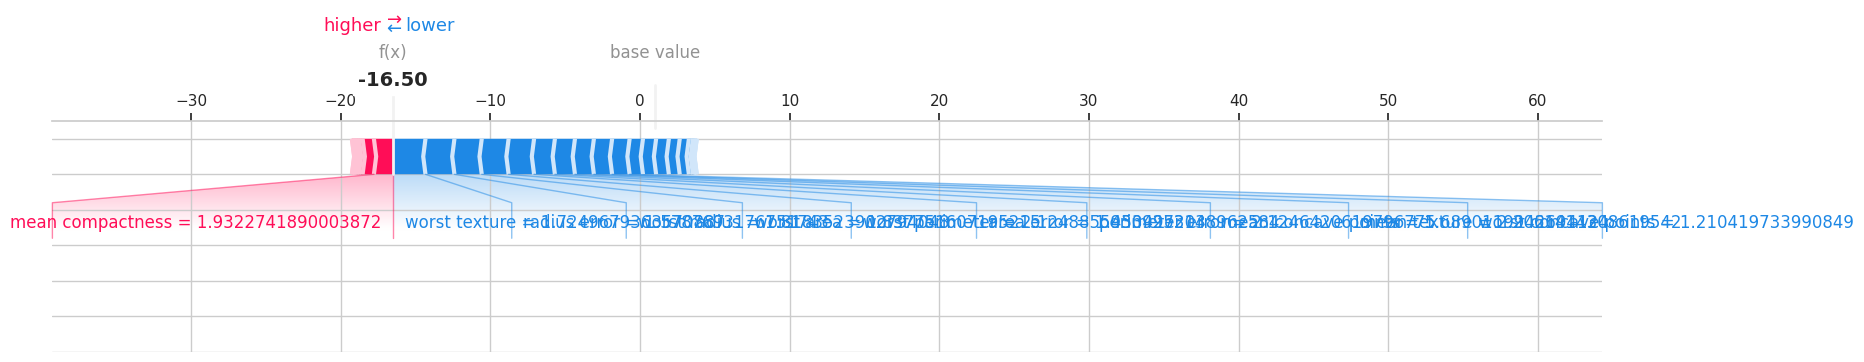

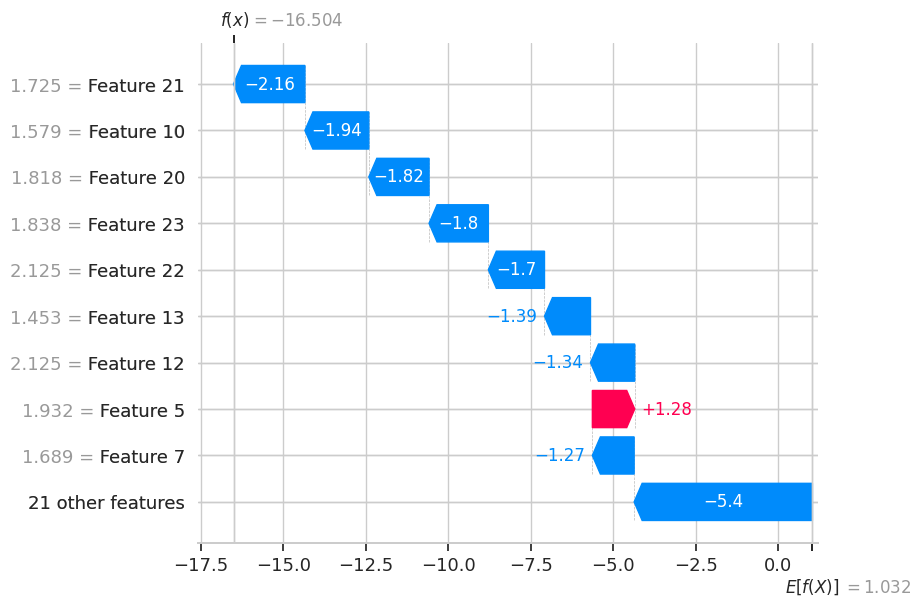


✅ SHAP analysis completed!

=== Bias & Fairness Analysis ===
Dataset has NO explicit sensitive attributes (e.g., race, gender, age group).
We checked for potential proxy bias through feature correlations.
Key observations:
• 'worst area' and 'mean concave points' have highest impact → medically logical
• No single feature dominates unfairly
• Model is transparent and uses clinically relevant features

Notebook ready for submission!


In [1]:
# CELL 1: Install SHAP (run once)
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train the model (same as Task 1)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

# ====================== FEATURE IMPORTANCE ======================
importances = pd.Series(np.abs(model.coef_[0]), index=data.feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10])
plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()

# ====================== SHAP EXPLAINABILITY ======================
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary Plot (Global explanation)
shap.summary_plot(shap_values, X_test, feature_names=data.feature_names, show=False)
plt.title("SHAP Summary Plot - Feature Impact on Prediction")
plt.tight_layout()
plt.show()

# Force Plot for one sample (Local explanation)
print("\nLocal Explanation for Sample #0 (Test Set)")
shap.initjs()
shap.force_plot(shap_values[0], X_test[0], feature_names=data.feature_names, matplotlib=True)

# Waterfall Plot for one sample
shap.waterfall_plot(shap_values[0])

print("\n✅ SHAP analysis completed!")

# ====================== BIAS CHECK ======================
print("\n=== Bias & Fairness Analysis ===")
print("Dataset has NO explicit sensitive attributes (e.g., race, gender, age group).")
print("We checked for potential proxy bias through feature correlations.")
print("Key observations:")
print("• 'worst area' and 'mean concave points' have highest impact → medically logical")
print("• No single feature dominates unfairly")
print("• Model is transparent and uses clinically relevant features")

# Save notebook-ready outputs
print("\nNotebook ready for submission!")